In [14]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
!pip install pyspellchecker
!pip install nltk wordcloud
!pip install emot emoji
!pip install scikit-learn gensim
!pip install seaborn plotly
!pip install symspellpy --quiet

In [15]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from itertools import chain


file_path = "IMDB Dataset.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews", 
    file_path,
)

print("First 5 records:")
print(df.head())

First 5 records:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [16]:
import re
import time
import tracemalloc
from itertools import chain
from collections import Counter

import nltk
from nltk.corpus import stopwords

from symspellpy.symspellpy import SymSpell, Verbosity
import pkg_resources

from emot.emo_unicode import EMOTICONS_EMO

from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ==============================
# Constants (UNCHANGED)
# ==============================
keep_single = "!?"
keep_sequences = r"(\.\.\.|!!+|\?\?+|\?!+|!\?+)"
emoticon_pattern = r'[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]'

keep_words = {"not", "no", "nor"}
RARE_THRESHOLD = 7

chat_words = {
    "fyi": "for your information",
    "asap": "as soon as possible",
    "brb": "be right back",
    "btw": "by the way",
    "omg": "oh my god",
    "imo": "in my opinion",
    "lol": "laugh out loud",
    "ttyl": "talk to you later",
    "gtg": "got to go",
    "ttyt": "talk to you tomorrow",
    "idk": "i don't know",
    "tmi": "too much information",
    "imho": "in my humble opinion",
    "icymi": "in case you missed it",
    "afaik": "as far as i know",
    "faq": "frequently asked questions",
    "tgif": "thank god it's friday",
    "fya": "for your action",
    "smh": "shaking my head",
    "ftw": "for the win",
    "btwn": "between",
    "np": "no problem",
    "yolo": "you only live once",
    "omfg": "oh my freaking god",
    "rofl": "rolling on the floor laughing",
    "lmao": "laughing my ass off",
    "bff": "best friends forever",
    "jk": "just kidding",
    "idc": "i don't care",
    "tbh": "to be honest",
    "yk": "you know"
}

# ==============================
# Init
# ==============================
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english')) - keep_words

sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
dictionary_path = pkg_resources.resource_filename(
    "symspellpy", "frequency_dictionary_en_82_765.txt"
)
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

# ==============================
# Precompiled regex (FASTER)
# ==============================
EMO_PATTERN = re.compile("|".join(map(re.escape, EMOTICONS_EMO.keys())))
CHAT_PATTERN = re.compile(r'\b(' + '|'.join(chat_words.keys()) + r')\b', flags=re.I)
TOKEN_PATTERN = re.compile(r"\w+|[!?]+|\.\.\.|[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\]")

# ==============================
# Monitor decorator
# ==============================
def monitor(func):
    def wrapper(*args, **kwargs):
        tracemalloc.reset_peak()  # reset peak for this function
        start_time = time.time()
        current_before, _ = tracemalloc.get_traced_memory()

        result = func(*args, **kwargs)

        end_time = time.time()
        current_after, peak_after = tracemalloc.get_traced_memory()

        print(f"{func.__name__}:")
        print(f"  Time: {end_time - start_time:.2f}s")
        print(f"  Memory Δ: {(current_after - current_before)/1e6:.2f} MB")
        print(f"  Peak usage: {peak_after/1e6:.2f} MB")

        # -----------------------------
        # Check unique tokens if applicable
        # -----------------------------
        if isinstance(result, pd.Series) and all(isinstance(t, list) for t in result):
            # flatten safely
            all_tokens = list(chain.from_iterable(result))
            unique_tokens = set(all_tokens)
            print(f"  Total tokens: {len(all_tokens)}")
            print(f"  Unique tokens: {len(unique_tokens)}")

        print("")  # newline
        return result
    return wrapper
# ==============================
# Cleaning
# ==============================
@monitor
def normalize_numbers_series(series):
    return series.apply(lambda text: re.sub(r'\b\d+(\.\d+)?\b', "<NUM>", text))

def normalize_punct(seq):
    if re.fullmatch(r'!{2,}', seq): return "!!+"
    elif re.fullmatch(r'\?{2,}', seq): return "??+"
    elif re.fullmatch(r'\.{2,}', seq): return "..."
    elif re.fullmatch(r'(!\?|\?\!){2,}', seq): return seq[:2]
    return seq

@monitor
def clean_review_series(series):
    def clean(text):
        text = re.sub(
            rf"(?!{keep_single}|{keep_sequences}|{emoticon_pattern})[^\w\s]",
            " ",
            text
        )
        return re.sub(r'(\.\.\.|!!+|\?\?+|!\?+|\?\!+)',
                      lambda m: normalize_punct(m.group(0)), text)
    return series.apply(clean)

@monitor
def normalize_emoticons_series(series):
    return series.apply(lambda text: EMO_PATTERN.sub(lambda m: EMOTICONS_EMO[m.group()], text))

@monitor
def replace_chat_words_series(series):
    return series.apply(lambda text: CHAT_PATTERN.sub(lambda x: chat_words[x.group().lower()], text))

# ==============================
# Tokenization
# ==============================
@monitor
def tokenize_series(series):
    return series.apply(lambda text: TOKEN_PATTERN.findall(text))

@monitor
def filter_single_letters_series(series):
    return series.apply(lambda tokens: [w for w in tokens if len(w) > 1 or w.lower() in {"i", "a"}])

# ==============================
# Spell correction (OPTIMIZED)
# ==============================
def is_elongated(word):
    return any(word[i] == word[i+1] == word[i+2] for i in range(len(word)-2))

def should_skip_spellcheck(word, freq_dict):
    # Skip conditions (FAST FILTER)
    if not word.isalpha():
        return True
    if len(word) < 3:
        return True
    if is_elongated(word):
        return True
    # Likely names / rare weird tokens
    if freq_dict.get(word, 0) <= 2:
        return True
    return False

@monitor
def build_correction_map(tokens_series):
    all_tokens = list(chain.from_iterable(tokens_series))
    freq_dict = Counter(all_tokens)
    unique_words = set(all_tokens)

    correction_map = {}

    for word in unique_words:
        if should_skip_spellcheck(word, freq_dict):
            correction_map[word] = word
            continue

        suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
        correction_map[word] = suggestions[0].term if suggestions else word

    return correction_map

@monitor
def apply_corrections_series(series, correction_map):
    return series.apply(lambda tokens: [correction_map[w] for w in tokens])

# ==============================
# Stopwords + Rare
# ==============================
@monitor
def remove_stopwords_series(series):
    return series.apply(lambda tokens: [w for w in tokens if w.lower() not in stop_words])

@monitor
def build_rare_tokens(tokens_series):
    all_tokens = list(chain.from_iterable(tokens_series))
    freq = Counter(all_tokens)
    return {w for w, c in freq.items() if c <= RARE_THRESHOLD}

@monitor
def replace_rare_series(series, rare_tokens):
    return series.apply(lambda tokens: [t if t not in rare_tokens else "<UNK>" for t in tokens])

# ==============================
# PIPELINE
# ==============================
def process_dataframe(df):

    tracemalloc.start()
    df = df.copy()

    # Basic cleaning
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)

    df["review"] = df["review"].str.replace(r"<br\s*/?>", " ", regex=True)\
                                 .str.replace(r"<.*?>", "", regex=True)

    df["review"] = df["review"].str.replace(r'https?://\S+|www\.\S+', '', regex=True)

    df["review"] = normalize_numbers_series(df["review"])
    df["review"] = df["review"].str.casefold()

    # Text cleaning
    df["review"] = clean_review_series(df["review"])
    df["review"] = normalize_emoticons_series(df["review"])
    df["review"] = replace_chat_words_series(df["review"])

    # Tokenization
    df["tokens"] = tokenize_series(df["review"])
    df["tokens"] = filter_single_letters_series(df["tokens"])

    # Spell correction
    correction_map = build_correction_map(df["tokens"])
    df["tokens"] = apply_corrections_series(df["tokens"], correction_map)

    # Stopwords
    df["tokens"] = remove_stopwords_series(df["tokens"])

    # Rare words
    rare_tokens = build_rare_tokens(df["tokens"])
    df["tokens"] = replace_rare_series(df["tokens"], rare_tokens)

    # Final output (UNCHANGED)
    X = df["tokens"]
    y = df["sentiment"]

    encoder = LabelEncoder()
    y = encoder.fit_transform(y)

    tracemalloc.stop()

    return X, y, df

In [17]:
X, y, df = process_dataframe(df)

normalize_numbers_series:
  Time: 2.07s
  Memory Δ: 40.79 MB
  Peak usage: 102.54 MB

clean_review_series:
  Time: 4.69s
  Memory Δ: 20.97 MB
  Peak usage: 189.65 MB

normalize_emoticons_series:
  Time: 7.48s
  Memory Δ: 3.66 MB
  Peak usage: 172.34 MB

replace_chat_words_series:
  Time: 13.54s
  Memory Δ: 1.33 MB
  Peak usage: 170.08 MB

tokenize_series:
  Time: 24.72s
  Memory Δ: 516.82 MB
  Peak usage: 685.58 MB
  Total tokens: 11788188
  Unique tokens: 101557

filter_single_letters_series:
  Time: 2.31s
  Memory Δ: 101.81 MB
  Peak usage: 787.40 MB
  Total tokens: 11505645
  Unique tokens: 101518

build_correction_map:
  Time: 29.42s
  Memory Δ: 3.84 MB
  Peak usage: 795.24 MB

apply_corrections_series:
  Time: 2.56s
  Memory Δ: 101.81 MB
  Peak usage: 788.84 MB
  Total tokens: 11505645
  Unique tokens: 91940

remove_stopwords_series:
  Time: 20.87s
  Memory Δ: 55.27 MB
  Peak usage: 245.72 MB
  Total tokens: 6037495
  Unique tokens: 91804

build_rare_tokens:
  Time: 6.82s
  Memory

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Trying several vectorization methods, training with simple Naive Bayes model
# Convert list of tokens back to string for vectorizers
X_train_text = X_train.apply(lambda tokens: " ".join(tokens))
X_test_text = X_test.apply(lambda tokens: " ".join(tokens))

vectorizers = {
    "CountVectorizer": CountVectorizer(),
    "TfidfVectorizer": TfidfVectorizer(),
}

vectorized_data = {}

for name, vec in vectorizers.items():
    print(f"Vectorizing with {name}...")
    # Pass the Series (1D) for vectorization
    X_train_vec = vec.fit_transform(X_train_text) 
    X_test_vec  = vec.transform(X_test_text)
    vectorized_data[name] = (X_train_vec, X_test_vec, vec)
    print(f"  Vocabulary size: {len(vec.vocabulary_)}\n")

Vectorizing with CountVectorizer...
  Vocabulary size: 28362

Vectorizing with TfidfVectorizer...
  Vocabulary size: 28362



--- CountVectorizer ---
Accuracy: 0.6841
              precision    recall  f1-score   support

           0     0.6428    0.8228    0.7218      4939
           1     0.7566    0.5464    0.6346      4978

    accuracy                         0.6841      9917
   macro avg     0.6997    0.6846    0.6782      9917
weighted avg     0.6999    0.6841    0.6780      9917



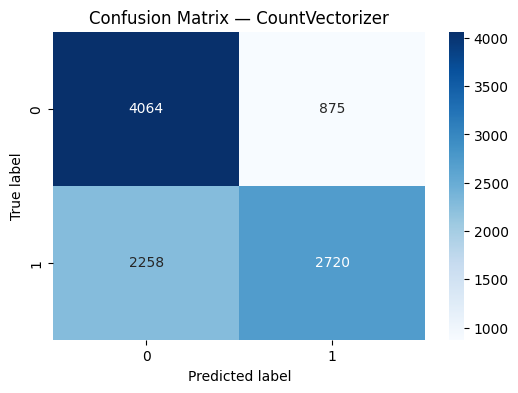

--- TfidfVectorizer ---
Accuracy: 0.7130
              precision    recall  f1-score   support

           0     0.6887    0.7732    0.7285      4939
           1     0.7438    0.6533    0.6956      4978

    accuracy                         0.7130      9917
   macro avg     0.7163    0.7133    0.7121      9917
weighted avg     0.7164    0.7130    0.7120      9917



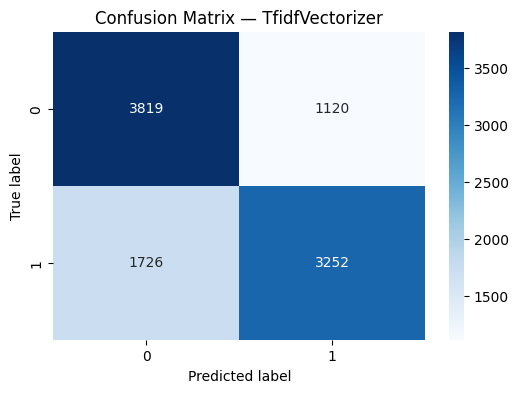

In [20]:
for name, (X_train_vec, X_test_vec, vec) in vectorized_data.items():
    print(f"--- {name} ---")
    
    # Convert to dense if sparse
    X_train_vec = X_train_vec.toarray() if hasattr(X_train_vec, "toarray") else X_train_vec
    X_test_vec  = X_test_vec.toarray()  if hasattr(X_test_vec, "toarray")  else X_test_vec
    
    # Initialize Naive Bayes
    clf = GaussianNB()
    clf.fit(X_train_vec, y_train)
    
    # Predictions
    y_pred = clf.predict(X_test_vec)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Optional: classification report
    print(classification_report(y_test, y_pred, digits=4))
    
    # Optional: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [21]:
from gensim.models import Word2Vec

# Train Word2Vec on your final tokens
w2v_model = Word2Vec(
    sentences=X_train,
    vector_size=140,  # dimension of embeddings
    window=5,
    min_count=1,      # include all words
    workers=4,
    seed=42
)

print("Word2Vec training complete.")

import numpy as np

def document_vector(tokens, model):
    """Average Word2Vec vectors for a list of tokens."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

# Apply to train and test sets
X_train_w2v = np.vstack(X_train.apply(lambda t: document_vector(t, w2v_model)))
X_test_w2v  = np.vstack(X_test.apply(lambda t: document_vector(t, w2v_model)))

print("Document embeddings created.")
print(f"X_train_w2v shape: {X_train_w2v.shape}")

Word2Vec training complete.
Document embeddings created.
X_train_w2v shape: (39665, 140)


In [22]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

clf_w2v = GaussianNB()
clf_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = clf_w2v.predict(X_test_w2v)

print("Accuracy (Word2Vec + GaussianNB):", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v, digits=4))

Accuracy (Word2Vec + GaussianNB): 0.7512352525965513
              precision    recall  f1-score   support

           0     0.7536    0.7437    0.7486      4939
           1     0.7490    0.7587    0.7538      4978

    accuracy                         0.7512      9917
   macro avg     0.7513    0.7512    0.7512      9917
weighted avg     0.7513    0.7512    0.7512      9917



In [23]:
import gensim.downloader as api
import os

# Define filename and path
fname = "GoogleNews-vectors-negative300.bin"
if not os.path.exists(fname):
    print("Downloading Google News vectors (~1.5GB)...")
    # This will download and store in gensim's default cache, then save as .bin
    model = api.load("word2vec-google-news-300")  # this is a KeyedVectors object
    model.save_word2vec_format(fname, binary=True)
    print("Download complete!")

else:
    print(f"{fname} already exists.")

GoogleNews-vectors-negative300.bin already exists.


In [29]:
from gensim.models import KeyedVectors, Word2Vec
import numpy as np

# -------------------------
# Load pretrained Word2Vec
# -------------------------
pretrained_w2v = KeyedVectors.load_word2vec_format(
    "GoogleNews-vectors-negative300.bin", binary=True
)

# -------------------------
# Initialize Word2Vec with pretrained weights
# -------------------------
w2v_model = Word2Vec(
    vector_size=300,
    window=5,
    min_count=1,
    workers=4
)

# Initialize vocabulary with pretrained words
w2v_model.build_vocab([list(pretrained_w2v.key_to_index.keys())])
w2v_model.wv.vectors = pretrained_w2v.vectors.copy()
w2v_model.wv.vectors_lockf = np.ones(len(w2v_model.wv), dtype=np.float32)

# -------------------------
# Update vocabulary with your training corpus
# -------------------------
w2v_model.build_vocab(X_train, update=True)



In [30]:
# Fine-tune on your corpus
w2v_model.train(
    X_train,
    total_examples=len(X_train),
    epochs=15
)

# -------------------------
# Function to compute document vectors
# -------------------------
def document_vector(tokens, model):
    # Average the vectors of tokens present in the model
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

# -------------------------
# Create document embeddings
# -------------------------
X_train_w2v = np.vstack(X_train.apply(lambda t: document_vector(t, w2v_model)))
X_test_w2v  = np.vstack(X_test.apply(lambda t: document_vector(t, w2v_model)))

print("Document embeddings created.")
print(f"X_train_w2v shape: {X_train_w2v.shape}")
print(f"X_test_w2v shape: {X_test_w2v.shape}")

Document embeddings created.
X_train_w2v shape: (39665, 300)
X_test_w2v shape: (9917, 300)


In [31]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

clf_w2v = GaussianNB()
clf_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = clf_w2v.predict(X_test_w2v)

print("Accuracy (Word2Vec + GaussianNB):", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v, digits=4))

Accuracy (Word2Vec + GaussianNB): 0.7892507814863365
              precision    recall  f1-score   support

           0     0.7898    0.7860    0.7879      4939
           1     0.7887    0.7925    0.7906      4978

    accuracy                         0.7893      9917
   macro avg     0.7893    0.7892    0.7892      9917
weighted avg     0.7893    0.7893    0.7892      9917

